# Data Analysis Of Blinkit Dataset
## By Python

## Questions: 
https://docs.google.com/presentation/d/1sgTuH5SgEJe_qsjrbGOocv64Sv6OVBzk/edit?slide=id.p1#slide=id.p1

### Importing libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Dataset

In [4]:
df=pd.read_csv("blinkit_data.csv")

In [5]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [6]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


In [10]:
print("Size of data : ",df.shape)

Size of data :  (8523, 12)


In [12]:
print("Data Columns ",df.columns)

Data Columns  Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')


In [14]:
print("Data tupes of Columns \n",df.dtypes)

Data tupes of Columns 
 Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object


### Data cleaning

In [15]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [19]:
df["Item Fat Content"]= df["Item Fat Content"].replace({'LF': 'Low Fat',
                                                       'low fat' : 'Low Fat',
                                                       'reg' : 'Regular'})

In [21]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,Low Fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,Low Fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,Low Fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,Regular,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,Regular,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


In [22]:
print(df["Item Fat Content"].unique())

['Regular' 'Low Fat']


## Answers of Above given Questions


### KPI Requirement

In [27]:
# Total Sales
total_sales=df["Sales"].sum()

# Average sales
avg_sales=df["Sales"].mean()

# No of items Sold
item_sold= df['Sales'].count()

# Average Rating
avg_rate= df['Rating'].mean()

# Display
print("Total Sales=",total_sales)
print("Average Sales=",avg_sales)
print("No of items Sold=",item_sold)
print("Average Rating=",avg_rate)


Total Sales= 1201681.4808
Average Sales= 140.9927819781767
No of items Sold= 8523
Average Rating= 3.965857092573038


### Chart Requirement

#### Total Sales by Fat Contents

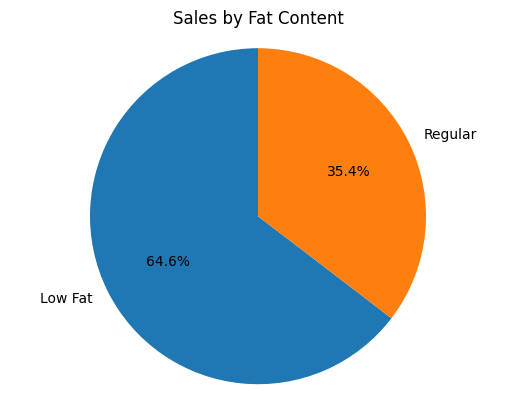

In [29]:
sales_by_fat= df.groupby('Item Fat Content')['Sales'].sum()

plt.pie(sales_by_fat, labels =sales_by_fat.index, autopct= '%.1f%%', startangle= 90)
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

#### Total Sales by Items

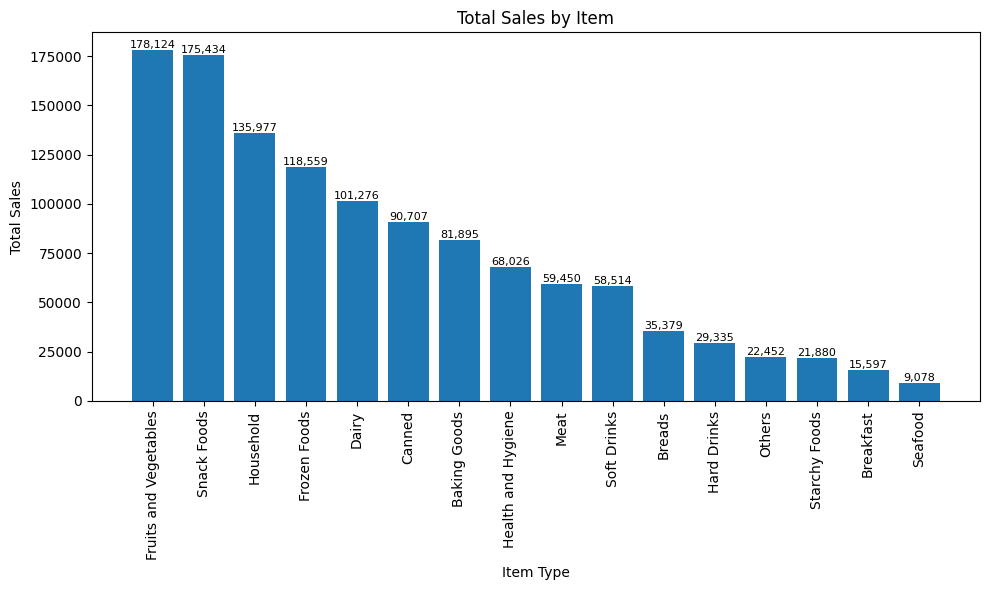

In [35]:
sales_by_type=df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars=plt.bar(sales_by_type.index,sales_by_type.values)

plt.xticks(rotation=90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2 ,bar.get_height(),
            f'{bar.get_height():,.0f}' , ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#### Fat Content by Outlet for Total Sales

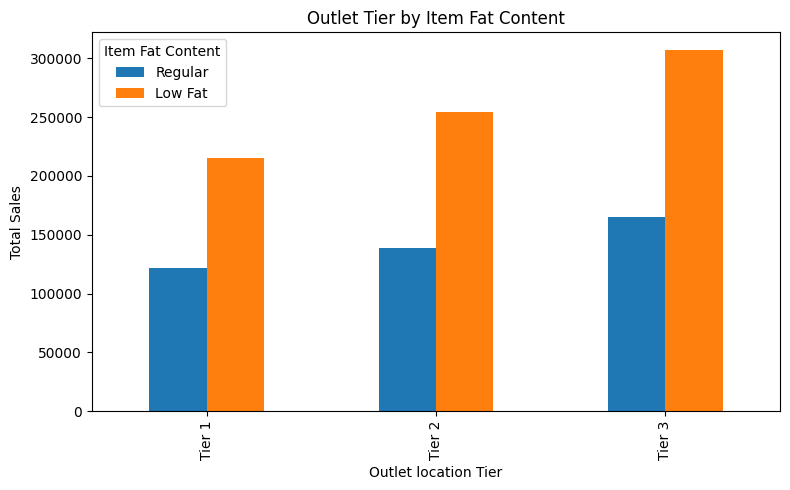

In [38]:
grouped= df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
grouped= grouped[['Regular','Low Fat']]

ax= grouped.plot(kind='bar', figsize=(8,5), title='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()


#### Total Sales by Outlet Establishment

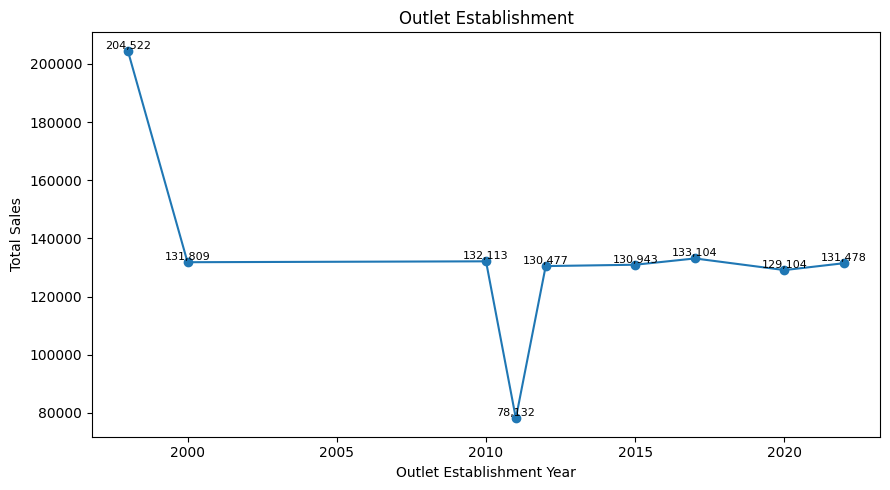

In [41]:
sale_year= df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sale_year.index,sale_year.values, marker='o',linestyle='-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x,y in zip(sale_year.index, sale_year.values):
    plt.text(x,y,f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#### Sales by Outlet Size

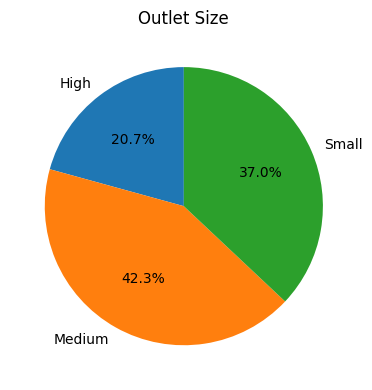

In [42]:
sales_size=df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_size, labels =sales_size.index, autopct= '%1.1f%%', startangle= 90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()


#### Sales by Outlet Location

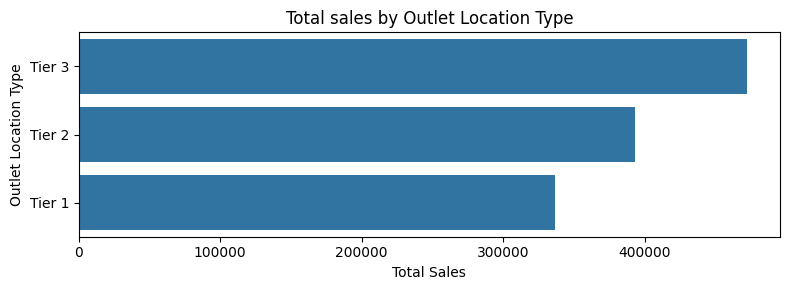

In [44]:
location= df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
location= location.sort_values('Sales',ascending=False)

plt.figure(figsize=(8,3))
ax= sns.barplot(x='Sales', y='Outlet Location Type', data=location)

plt.ylabel('Outlet Location Type')
plt.xlabel('Total Sales')
plt.title('Total sales by Outlet Location Type')

plt.tight_layout()
plt.show()


# Conclusion

This data analysis of the Blinkit dataset provides valuable insights into sales performance across various dimensions.

## Key Findings:
- **Total Sales and KPIs**: The dataset shows a total sales figure, with an average sales per item and an overall average rating, indicating customer satisfaction levels.
- **Sales by Fat Content**: Low Fat items dominate sales, suggesting a preference for healthier options.
- **Top Performing Item Types**: Fruits and Vegetables, Snack Foods, and Household items lead in sales, highlighting popular categories.
- **Outlet Performance**: Tier 3 outlets in urban locations show higher sales, while newer establishments (around 2009) have increased sales trends.
- **Outlet Size and Location**: Medium-sized outlets contribute significantly, and Tier 1 locations have the highest sales.

## Recommendations:
- Focus marketing on high-selling item types and low-fat products.
- Invest in Tier 3 urban outlets and consider expansion in high-performing locations.
- Monitor establishment year trends to optimize new store openings.

This analysis can guide business decisions for improved profitability and customer engagement.